In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "E:/icu_project/models/ui_backend_data.csv"
)

df.head()

,predicted_probability,true_label,deterioration_24h,cardiovascular,respiratory,renal,neurologic,metabolic,alert,ai_summary
0,0.028328,0.0,2.8,Normal,Normal,Stable,Normal,Stable,Stable,Patient stable. Continue routine monitoring.
1,0.713363,0.0,71.3,Critical,Critical,Failure Risk,Severe,Critical,Warning,Clinical deterioration likely. Physician revie...
2,0.018817,0.0,1.9,Normal,Normal,Stable,Normal,Stable,Stable,Patient stable. Continue routine monitoring.
3,0.225931,0.0,22.6,Normal,Normal,Stable,Normal,Stable,Stable,Patient stable. Continue routine monitoring.
4,0.508967,0.0,50.9,Stress,Compromised,Monitor,Reduced,Stress,Warning,Clinical deterioration likely. Physician revie...


In [3]:
time = np.arange(-4,1)

def simulate_map_response(p):

    baseline = 60
    improvement = (1 - p) * 25

    return np.linspace(
        baseline,
        baseline + improvement,
        5
    )

In [4]:
responses = []

for p in df["predicted_probability"][:20]:

    curve = simulate_map_response(p)

    responses.append(curve)

responses = np.array(responses)

responses.shape

(20, 5)

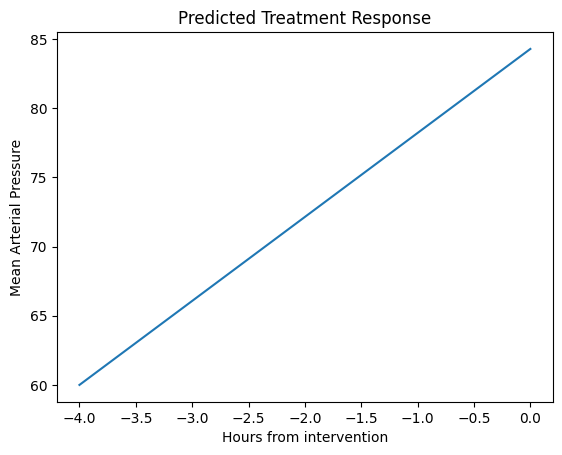

In [5]:
plt.plot(time, responses[0])

plt.xlabel("Hours from intervention")
plt.ylabel("Mean Arterial Pressure")

plt.title("Predicted Treatment Response")

plt.show()

In [6]:
df["map_response_curve"] = [
    simulate_map_response(p).tolist()
    for p in df["predicted_probability"]
]

In [7]:
df.to_csv(
    "E:/icu_project/models/ui_backend_data_v2.csv",
    index=False
)

In [ ]:
yes
